# Zad 1

In [58]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

np.random.seed(2137)
torch.manual_seed(2137)

In [59]:
housing = fetch_california_housing()

print(f"Data shape: {housing.data.shape}, Target shape: {housing.target.shape}")

print(f"Sample data: {housing.data[0:3]}")
print(f"Sample target: {housing.target[0:3]}")

Data shape: (20640, 8), Target shape: (20640,)
Sample data: [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]]
Sample target: [4.526 3.585 3.521]


In [60]:
X = torch.tensor(housing.data, dtype=torch.float32)
y = torch.tensor(housing.target, dtype=torch.float32).view(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=2137)

mean = torch.mean(X_train, dim=0)
std = torch.std(X_train, dim=0)

def normalize(X, mean, std):
    return (X - mean) / std

X_raw_train = X_train
X_raw_val = X_val

X_train = normalize(X_train, mean, std)
X_val = normalize(X_val, mean, std)

N, d = housing.data.shape

In [61]:
W = torch.randn(d, 1)

b = torch.randn(1)

W.requires_grad = True
b.requires_grad = True

In [62]:
def forward(x):
    return x @ W + b

def loss(y, y_pred):
    return torch.mean((y - y_pred)**2) 

In [63]:
epochs = 500
lr = 0.01

train_losses = []
val_losses = []

for epoch in range(epochs):
    y_pred_train = forward(X_train)

    loss_train = loss(y_train, y_pred_train)
    train_losses.append(loss_train.item())

    loss_train.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

        W.grad.zero_()
        b.grad.zero_()

    with torch.no_grad():
        y_pred_val = forward(X_val)
        loss_val = loss(y_val, y_pred_val)
        val_losses.append(loss_val.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss_train.item():.4f} | Val Loss: {loss_val.item():.4f}")

Epoch 10/500 | Train Loss: 13.8786 | Val Loss: 12.5238
Epoch 20/500 | Train Loss: 9.3147 | Val Loss: 8.4115
Epoch 30/500 | Train Loss: 6.5023 | Val Loss: 5.8979
Epoch 40/500 | Train Loss: 4.7283 | Val Loss: 4.3230
Epoch 50/500 | Train Loss: 3.5864 | Val Loss: 3.3142
Epoch 60/500 | Train Loss: 2.8379 | Val Loss: 2.6552
Epoch 70/500 | Train Loss: 2.3390 | Val Loss: 2.2164
Epoch 80/500 | Train Loss: 2.0008 | Val Loss: 1.9187
Epoch 90/500 | Train Loss: 1.7674 | Val Loss: 1.7126
Epoch 100/500 | Train Loss: 1.6030 | Val Loss: 1.5667
Epoch 110/500 | Train Loss: 1.4846 | Val Loss: 1.4607
Epoch 120/500 | Train Loss: 1.3969 | Val Loss: 1.3816
Epoch 130/500 | Train Loss: 1.3302 | Val Loss: 1.3207
Epoch 140/500 | Train Loss: 1.2776 | Val Loss: 1.2723
Epoch 150/500 | Train Loss: 1.2349 | Val Loss: 1.2326
Epoch 160/500 | Train Loss: 1.1992 | Val Loss: 1.1989
Epoch 170/500 | Train Loss: 1.1683 | Val Loss: 1.1696
Epoch 180/500 | Train Loss: 1.1410 | Val Loss: 1.1435
Epoch 190/500 | Train Loss: 1.1163 

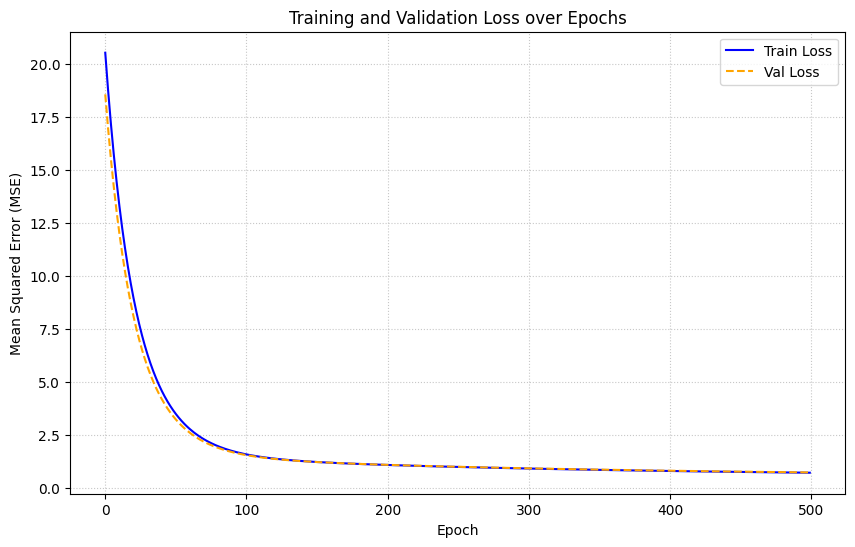

In [64]:
plt.figure(figsize=(10, 6))

plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange', linestyle='--')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

1. Why do we need torch.no_grad() during parameter update?
    * Nie chcemy żeby te obliczenia dostały się do grafu obliczeń, byłoby to nieporawne, a dodaktowo doprowadziło by do cyklu w grafie, który powinien być DAG'iem

2. Why must we reset gradients each iteration?
    * Każda iteracja ma kończy sie updatem, tamte gradietny byłby nieakutalne

3. Why does feature normalization typically help analyticalimization?
    *  normalizacja zmniejsza "rozstrzał" wartość, bezpieczniejsze są obliczenia z perskeptywy numerycznej


# Zad2

In [65]:
XTX = X_train.T @ X_train

XTX_inv = torch.linalg.pinv(XTX)

W_analytical = ((XTX_inv) @ X_train.T) @ y_train

b_analytical = torch.mean(y_train - (X_train @ W_analytical))

print(f"W*: {W_analytical}\nb*: {b_analytical}")


W*: tensor([[ 0.8277],
        [ 0.1145],
        [-0.2424],
        [ 0.2736],
        [-0.0090],
        [-0.0394],
        [-0.8973],
        [-0.8686]])
b*: 2.0690386295318604


In [66]:
y_pred_train_analytical = X_train @ W_analytical + b_analytical

loss_train_analytical = loss(y_train, y_pred_train_analytical)

y_pred_val_analytical = X_val @ W_analytical + b_analytical
loss_val_analytical = loss(y_val, y_pred_val_analytical)

print(f"Gradient Descent MSE (Train): {train_losses[-1]:.4f}")
print(f"Closed-Form MSE (Train): {loss_train_analytical.item():.4f}")
print("---")
print(f"Gradient Descent MSE (Val): {val_losses[-1]:.4f}")
print(f"Closed-Form MSE (Val): {loss_val_analytical.item():.4f}")

Gradient Descent MSE (Train): 0.7257
Closed-Form MSE (Train): 0.5241
---
Gradient Descent MSE (Val): 0.7397
Closed-Form MSE (Val): 0.5270


1. When is the closed-form solution feasible, and when is it not?
    * gdy cech jest mało, bo jest to bardzo złożone obliczeniowo (d^3), dodatkwo odwracanie macierzy to też nie jest stabilne numerycznie (teorytycznie macierz może nie być wcale odwracalna)
2. Why might gradient descent not match the closed-form result exactly (even on convex problems)?
    *  ze względów numerycznych, zakładając ze funkcja starty jest całkowicie wypułka, jest jedynie jedno lokalne minimum, to numeryczne błędy mogą nie pozwolić na dostateczną precyzje rozwiązania. dodatkowo metoda jest krokowa ... może być za mało kroków, źle skalibrowany learning rate, który możne niesutanie przeskaiwac minimum.

# A

# Geometria Różniczkowa Powierzchni Straty 

### wygenerowałem poniższy tekst, ale byłem na kursie z geometrii różniczkowej w IM i uważam, że warto to dobrze opisać, tak edukacyjnie

Aby w pełni zrozumieć wskaźnik uwarunkowania $\kappa$, możemy przeanalizować funkcję kosztu przez pryzmat geometrii hiperpowierzchni. Rozważmy funkcję błędu średniokwadratowego (pomijając stałe skalujące $\frac{1}{N}$ dla czystości zapisu):

$$\mathcal{L}(W) = \frac{1}{2} \| XW - y \|^2$$

Rozwijając tę normę kwadratową, możemy wyprowadzić wektor gradientu (pierwszą pochodną) oraz macierz Hesjanu (drugą pochodną):

1. **Gradient (Nachylenie powierzchni):**
$$\nabla \mathcal{L}(W) = X^T(XW - y) = X^TXW - X^Ty$$

2. **Hesjan (Krzywizna powierzchni):**
$$\mathcal{H}_{\mathcal{L}}(W) = \nabla^2 \mathcal{L}(W) = X^T X$$

Ponieważ $\mathcal{L}(W)$ to forma kwadratowa, jej Hesjan $X^T X$ jest stały w każdym punkcie hiperpowierzchni i jest macierzą symetryczną, dodatnio półokreśloną. 

W języku geometrii różniczkowej, w punkcie minimum lokalnego, Hesjan reprezentuje **Drugą Formę Podstawową**  (mierzy ona rzut drugiej pochodnej krzywej na wektor normalny  do powierzchni) .tej powierzchni. Jego wektory własne wyznaczają **kierunki główne** (kierunki maksymalnego i minimalnego zagięcia hiperparaboloidy), a odpowiadające im wartości własne $\lambda_i$ to dokładnie **krzywizny główne** (principal curvatures) w tych kierunkach, oznaczmy je jako $k_i$.

Stąd wskaźnik uwarunkowania to stosunek skrajnych krzywizn:
$$\kappa(X^T X) = \frac{\lambda_{\max}}{\lambda_{\min}} = \frac{k_{\max}}{k_{\min}}$$

**Krzywizna Gaussa a wyznacznik macierzy:**
Zgodnie z Teorema Egregium Gaussa, krzywizna Gaussa $K$ w danym punkcie to iloczyn wszystkich krzywizn głównych (na przekrojach wzdłuż wektorów własnych). W języku algebry liniowej iloczyn wartości własnych macierzy to po prostu jej wyznacznik:

$$K = \prod_{i=1}^d k_i = \prod_{i=1}^d \lambda_i = \det(X^T X)$$

In [67]:
H_raw = X_raw_train.T @ X_raw_train
H_norm = X_train.T @ X_train 

eigvals_raw = torch.linalg.eigvalsh(H_raw)
eigvals_norm = torch.linalg.eigvalsh(H_norm)

kappa_raw = eigvals_raw[-1] / eigvals_raw[0]
kappa_norm = eigvals_norm[-1] / eigvals_norm[0]

print("--- Condition Number (kappa) ---")
print(f"Surowe (Raw) dane:  {kappa_raw.item():.2e}")
print(f"Znormalizowane:     {kappa_norm.item():.2e}")
print(f"Różnica rzędów wielkości: ~{kappa_raw.item() / kappa_norm.item():.0e} razy mniejsza!")

--- Condition Number (kappa) ---
Surowe (Raw) dane:  1.03e+08
Znormalizowane:     4.44e+01
Różnica rzędów wielkości: ~2e+06 razy mniejsza!


1. Is the condition number larger without normalization?
    * tak, niemal 2 miliony razy więszky!
2. What does a large condition number indicate?
    * wzduż jednego kierunku hiperpowierchinia jest niemal płaską a wzdłuż pewnego innego keriunku mocnej zakrzywiona. Można o tym myśleć jak o długim, ale stromym kanionie. 
3. What happens if \lambda_{\min} \approx 0 ?
    * conajmniej w jednym kierunku hiperpowierzchnia jest niemal płaska, w dodatku jak wyzacnzik jest 0 to macierz jest osboliwa i nie możemy jej odwrócić, wiec nie mamy wtedy analitycznego wzoru, jeśli całość jest bliska 0, ale wciaz niezerowa to i tak napotykamy błedy numeryczne.

Możemna myślec, ze gdy minimalna warotśc własna jest bardzo bliska zeru (macierz jest >= 0 wiec nie mogą być ujemne) i ten condition number jest duzy to problem jest po prostu źle uwarunkowany, w rozumieniu tego co było na metodach numerycznych

# B

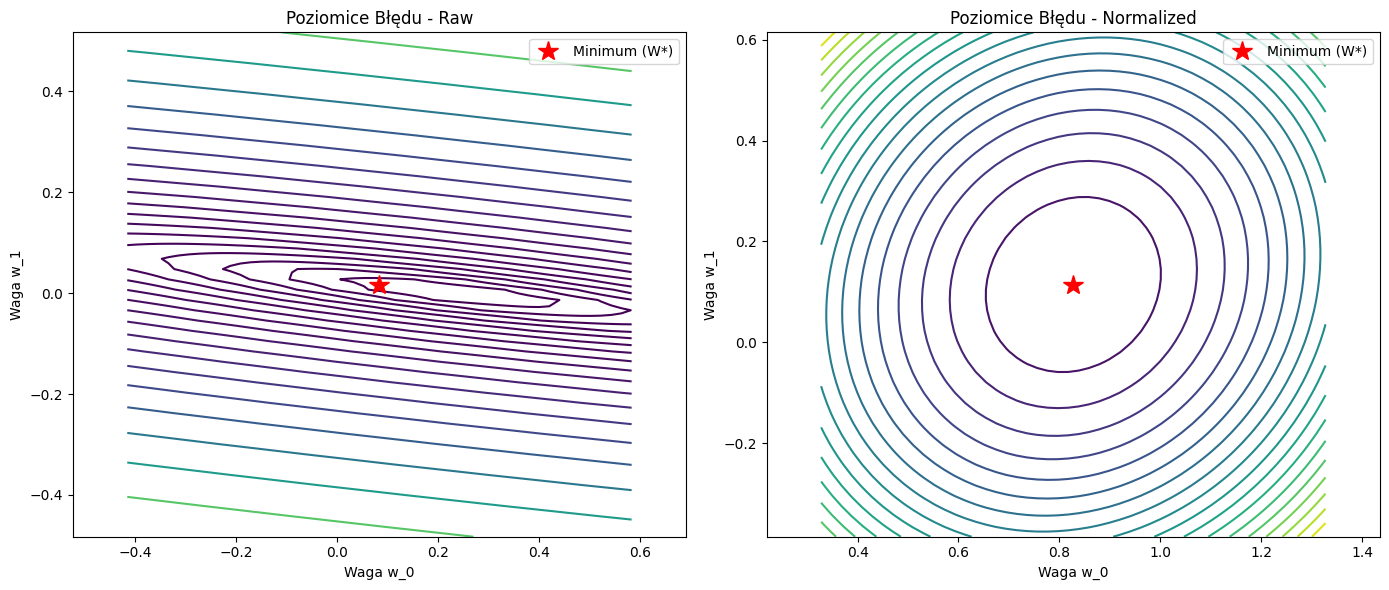

In [ ]:
W_analytical_raw = torch.linalg.pinv(X_raw_train.T @ X_raw_train) @ X_raw_train.T @ y_train
W_analytical_norm = torch.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train

b_analytical_raw = torch.mean(y_train - (X_raw_train @ W_analytical_raw))
b_analytical_norm = torch.mean(y_train - (X_train @ W_analytical_norm))

# wybieramy dwa kierunki wzdłuż ktorych będziemy badać wykres, jego krzywizne itp
idx1, idx2 = 0, 1 

def compute_loss_grid(X, y, W, b, idx1, idx2, span, steps=50):
    # parametr span mówi jak o zakresie wartości siatki a steps to 1/częstotliwość cięcia
    w1_vals = np.linspace(W[idx1].item() - span, W[idx1].item() + span, steps)
    w2_vals = np.linspace(W[idx2].item() - span, W[idx2].item() + span, steps)
    
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    Loss_Grid = np.zeros_like(W1)

    W_temp = W.clone()

    for i in range(steps):
        for j in range(steps):
            W_temp[idx1] = W1[i, j]
            W_temp[idx2] = W2[i, j]

            preds = X @ W_temp + b
            Loss_Grid[i, j] = torch.mean((preds - y)**2).item()
            
    return W1, W2, Loss_Grid

span = 0.5
W1_raw, W2_raw, L_raw = compute_loss_grid(X_raw_train, y_train, W_analytical_raw, b_analytical_raw, idx1, idx2, span=span)
W1_norm, W2_norm, L_norm = compute_loss_grid(X_train, y_train, W_analytical_norm, b_analytical_norm, idx1, idx2, span=span)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

levels_raw = np.logspace(np.log10(L_raw.min()), np.log10(L_raw.max()), 20)
c1 = axes[0].contour(W1_raw, W2_raw, L_raw, levels=levels_raw, cmap='viridis')
axes[0].plot(W_analytical_raw[idx1].item(), W_analytical_raw[idx2].item(), 'r*', markersize=15, label='Minimum (W*)')
axes[0].set_title('Poziomice Błędu - Raw')
axes[0].set_xlabel(f'Waga w_{idx1}')
axes[0].set_ylabel(f'Waga w_{idx2}')
axes[0].legend()
axes[0].axis('equal')

levels_norm = np.linspace(L_norm.min(), L_norm.max(), 20)
c2 = axes[1].contour(W1_norm, W2_norm, L_norm, levels=levels_norm, cmap='viridis')
axes[1].plot(W_analytical_norm[idx1].item(), W_analytical_norm[idx2].item(), 'r*', markersize=15, label='Minimum (W*)')
axes[1].set_title('Poziomice Błędu - Normalized')
axes[1].set_xlabel(f'Waga w_{idx1}')
axes[1].set_ylabel(f'Waga w_{idx2}')
axes[1].legend()
axes[1].axis('equal')

plt.tight_layout()
plt.show()

1. What is the shape of the contours without normalization?
    * Poziomice to elipsy, ale skrajnie zniekształcone – bardzo wąskie w jednym kierunku i nienaturalnie szerokie w drugim (tworzą kształt "kanionu").  
2. What is the shape after normalization?
    * Wciąż są to elipsy, ale znacznie bardziej symetryczne. Zbliżają się kształtem do jednolitych okręgów (kształt "miski").
3. Are they circular or elongated?
    * Dla danych surowych są mocno wydłużone (elongated), a po normalizacji stają się niemal okrągłe (circular).
4. How does this relate to the condition number?
    * Wartości własne Hesjanu w punkcie minimum determinują długości półosi tych elips. 
    
    Choć osie naszego wykresu (wybrane 2 wagi) nie muszą idealnie pokrywać się z wektorami własnymi, to właśnie wartości własne dyktują ten "rozstrzał" kształtu.
    
    Jeśli zapiszemy równanie poziomicy (gdzie błąd wynosi $C$) wzdłuż jej głównych kierunków, otrzymamy:
    $$\lambda_1 x^2 + \lambda_2 y^2 = C$$
    
    Przekształcając to do klasycznego równania elipsy:
    
    $$\frac{x^2}{(C/\lambda_1)} + \frac{y^2}{(C/\lambda_2)} = 1$$
    
    Widzimy, że długości półosi wynoszą $a = \frac{\sqrt{C}}{\sqrt{\lambda_1}}$ oraz $b = \frac{\sqrt{C}}{\sqrt{\lambda_2}}$.
    
    Stosunek najdłuższej półosi do najkrótszej to dokładnie $\sqrt{\kappa}$:
    
    $$\frac{a}{b} = \frac{\sqrt{C}/\sqrt{\lambda_{\min}}}{\sqrt{C}/\sqrt{\lambda_{\max}}} = \frac{\sqrt{\lambda_{\max}}}{\sqrt{\lambda_{\min}}} = \sqrt{\kappa}$$
    
    Wniosek: duży wskaźnik $\kappa$ oznacza bezpośrednio, że elipsa jest skrajnie rozciągnięta w jednym z kierunków.

# Zad3

In [69]:
def train_experiment(X_tr, y_tr, X_v, y_v, lr, epochs=100):
    N_tr, d_tr = X_tr.shape
    W = torch.randn(d_tr, 1, requires_grad=True)
    b = torch.randn(1, requires_grad=True)
    
    train_losses = []
    val_losses = []
    grad_norms = []
    
    for epoch in range(epochs):
        y_pred_train = X_tr @ W + b
        loss_train = torch.mean((y_pred_train - y_tr)**2)
        
        loss_train.backward()
        
        train_losses.append(loss_train.item())
        grad_norms.append(torch.norm(W.grad).item())
        
        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad
            
            W.grad.zero_()
            b.grad.zero_()
            
        with torch.no_grad():
            y_pred_test = X_v @ W + b
            loss_test = torch.mean((y_pred_test - y_v)**2)
            val_losses.append(loss_test.item())
            
    return train_losses, val_losses, grad_norms

In [70]:
lr_norm = {
    "Too Small": 0.0001,
    "Reasonable": 0.01,
    "Too Large": 1
}

# lr_raw = {
#     "Too Small": 0.0001,
#     "Reasonable": 0.01,
#     "Too Large": 1
# }

lr_raw = {
    "Too Small": 1e-8,
    "Reasonable": 1e-6,
    "Too Large": 1e-3
}

In [71]:
results_norm = {}
results_raw = {}

In [72]:
for name, lr in lr_norm.items():
    t_loss, v_loss, g_norms = train_experiment(X_train, y_train, X_val, y_val, lr)
    results_norm[name] = {"train_loss": t_loss, "val_loss": v_loss, "grad_norm": g_norms}
    print(f"[{name}] LR={lr} | Final Train MSE: {t_loss[-1]:.4f}")

for name, lr in lr_raw.items():
    t_loss, v_loss, g_norms = train_experiment(X_raw_train, y_train, X_raw_val, y_val, lr)
    results_raw[name] = {"train_loss": t_loss, "val_loss": v_loss, "grad_norm": g_norms}
    print(f"[{name}] LR={lr} | Final Train MSE: {t_loss[-1]:.4f}")

[Too Small] LR=0.0001 | Final Train MSE: 24.1133
[Reasonable] LR=0.01 | Final Train MSE: 1.0447
[Too Large] LR=1 | Final Train MSE: nan
[Too Small] LR=1e-08 | Final Train MSE: 4632.5747
[Reasonable] LR=1e-06 | Final Train MSE: nan
[Too Large] LR=0.001 | Final Train MSE: nan


In [73]:
def plot_results(results_dict, lr_dict, title):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=16)

    for i, (name, data) in enumerate(results_dict.items()):
        epochs_range = range(len(data["train_loss"]))
        
        axes[0, i].plot(epochs_range, data["train_loss"], label='Train Loss', color='blue')
        axes[0, i].plot(epochs_range, data["val_loss"], label='Val Loss', color='orange', linestyle='--')
        axes[0, i].set_title(f"{name} (LR={lr_dict[name]})")
        axes[0, i].set_xlabel("Epoch")
        axes[0, i].set_ylabel("MSE Loss")
        axes[0, i].legend()
        axes[0, i].grid(True, linestyle=':', alpha=0.7)
        
        if name == "Too Large":
            axes[0, i].set_yscale('log')
        
        axes[1, i].plot(epochs_range, data["grad_norm"], label='Gradient Norm', color='red')
        axes[1, i].set_xlabel("Epoch")
        axes[1, i].set_ylabel("|| Grad ||_2")
        axes[1, i].legend()
        axes[1, i].grid(True, linestyle=':', alpha=0.7)
        
        if name == "Too Large":
             axes[1, i].set_yscale('log')

    plt.tight_layout()
    plt.show()

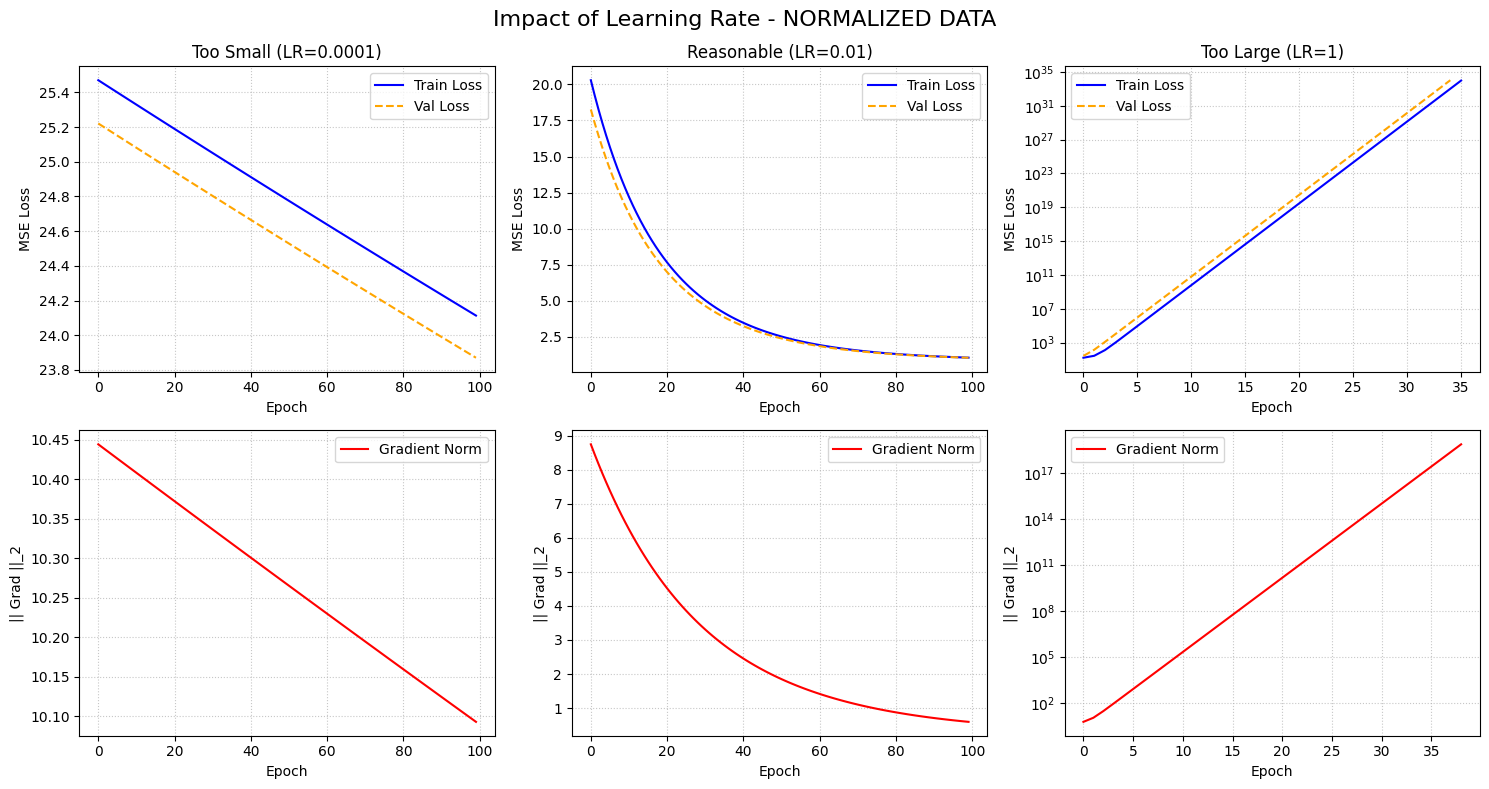

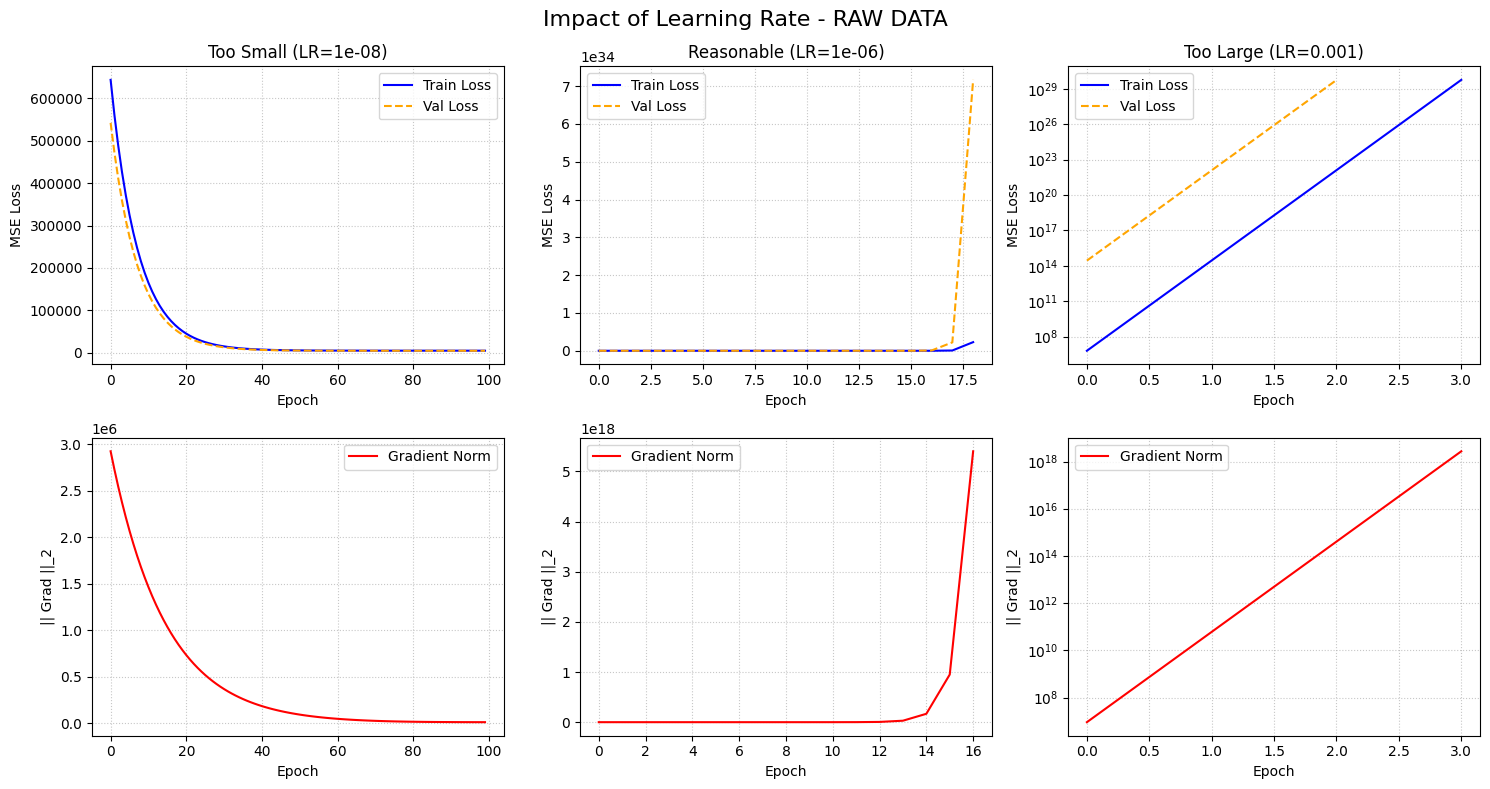

In [74]:
plot_results(results_norm, lr_norm, "Impact of Learning Rate - NORMALIZED DATA")
plot_results(results_raw, lr_raw, "Impact of Learning Rate - RAW DATA")

Dla raw data trenig ma sens gdy learning rate jest ekstremalnie mały, także trzeba normalizować!

1. What does divergence look like in the loss curve?
    * ogromy wzrost błędu i wielkości gradientu w trzeciej kolumnie
2. Explain why too-large learning rate causes instability.
    * jak zaczniemy odpowiednio "wysoko" w dolinie to gradient będzie dłuższy od szerokości doliny (jeśli jest ona odpowiednio stroma), więc bedziemy nieustanie przeskakiwać na przeciwległy brzeg i tak coraz wyżej i wyżej ... 
3. How does **normalization** affect the range of “reasonable” learning rates?
    * Tak jak można było zauwazyc w poprzednich zdaniach, nieznoramlziowane dane dopuszczają sytuacje w której "doliny są bardzo wąskie", wtedy nawet nieduzy lr może nas cały czas przerzucać ponad minimum. Zadbanie o noramlizaje poprawia kontrole nad procesem uczenia.